# EDA — merged.csv (all_v2 + input_data, 2018–2021)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (13, 5)

In [51]:
df = pd.read_csv('../data/processed/merged.csv', parse_dates=['date'])
print('Shape:', df.shape)
print()
print('Типы данных:')
print(df.dtypes)
print()
print('Пропуски:')
print(df.isnull().sum())

Shape: (16832702, 12)

Типы данных:
date            datetime64[us]
price                    int64
level                    int64
levels                   int64
rooms                    int64
area                   float64
kitchen_area           float64
geo_lat                float64
geo_lon                float64
object_type              int64
region                 float64
source                     str
dtype: object

Пропуски:
date            0
price           0
level           0
levels          0
rooms           0
area            0
kitchen_area    0
geo_lat         0
geo_lon         0
object_type     0
region          0
source          0
dtype: int64


## 1. Временное распределение

Период: 2018-02-19 — 2021-12-31

Записей по годам и источникам:
source   all_v2  input_data
date                       
2018     871517           0
2019    2233723           0
2020    1802377           0
2021     566935    11358150


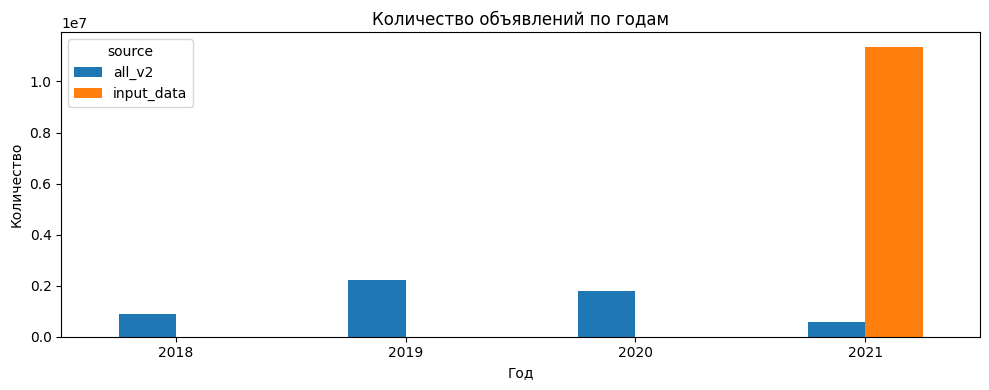

In [52]:
print('Период:', df['date'].min().date(), '—', df['date'].max().date())
print()
by_year = df.groupby([df['date'].dt.year, 'source']).size().unstack(fill_value=0)
print('Записей по годам и источникам:')
print(by_year)

by_year.plot(kind='bar', figsize=(10, 4))
plt.title('Количество объявлений по годам')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Целевая переменная — цена

In [53]:
print(df['price'].describe().apply(lambda x: f'{x:,.0f}'))
print()
print(f'Нулевые цены:    {(df["price"] == 0).sum():,}')
print(f'Цены > 1 млрд:   {(df["price"] > 1_000_000_000).sum():,}')
print(f'Цены < 100 тыс:  {(df["price"] < 100_000).sum():,}')

count         16,832,702
mean           6,017,586
std          162,875,242
min       -2,144,967,296
25%            2,350,000
50%            3,650,000
75%            5,971,121
max      635,552,400,000
Name: price, dtype: str

Нулевые цены:    8,123
Цены > 1 млрд:   1,525
Цены < 100 тыс:  14,999


Записей в диапазоне 300к–30млн: 16,571,541 (98.4%)


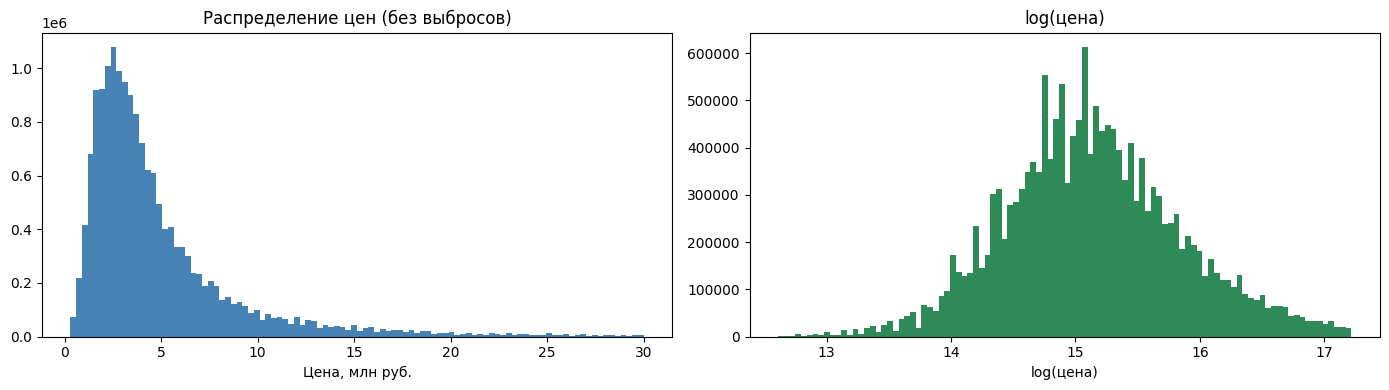

In [54]:
price_clean = df[(df['price'] > 300_000) & (df['price'] < 30_000_000)]['price']
print(f'Записей в диапазоне 300к–30млн: {len(price_clean):,} ({len(price_clean)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(price_clean / 1e6, bins=100, color='steelblue')
axes[0].set_title('Распределение цен (без выбросов)')
axes[0].set_xlabel('Цена, млн руб.')

axes[1].hist(np.log1p(price_clean), bins=100, color='seagreen')
axes[1].set_title('log(цена)')
axes[1].set_xlabel('log(цена)')

plt.tight_layout()
plt.show()

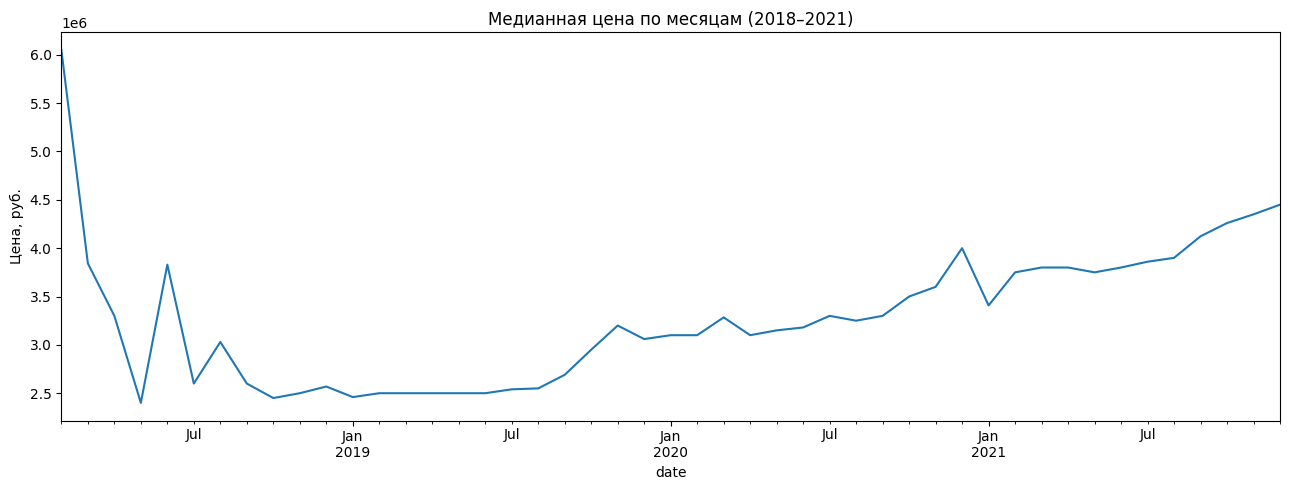

In [55]:
# Медианная цена по месяцам
df_clean = df[(df['price'] > 300_000) & (df['price'] < 30_000_000)].copy()
monthly = df_clean.groupby(df_clean['date'].dt.to_period('M'))['price'].median()
monthly.plot(title='Медианная цена по месяцам (2018–2021)', ylabel='Цена, руб.')
plt.tight_layout()
plt.show()

## 3. Признаки объекта

rooms: [np.int64(-2), np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
object_type (0=вторичка, 1=новостройка): {0: 12225709, 1: 4606993}



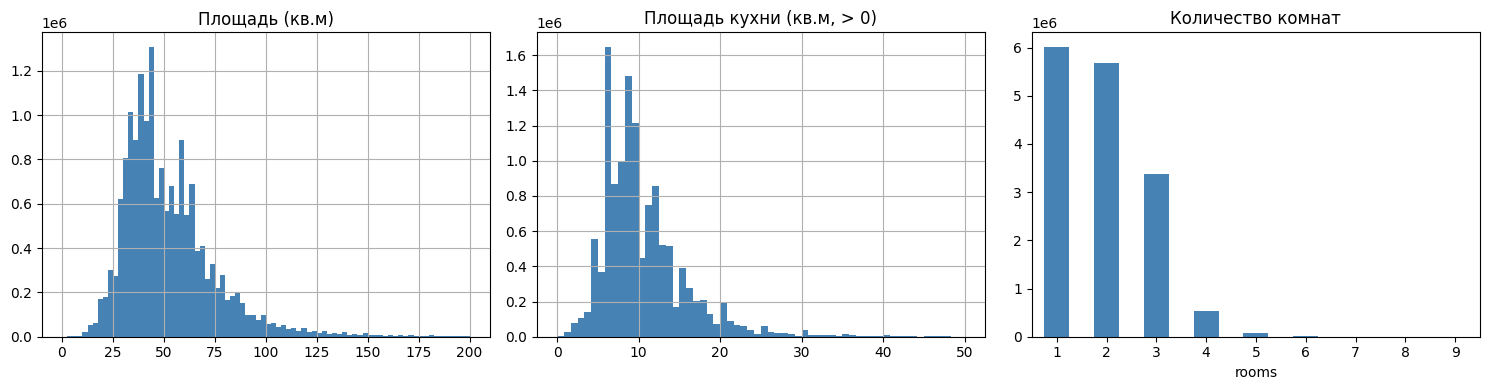

In [56]:
print('rooms:', sorted(df['rooms'].unique()))
print('object_type (0=вторичка, 1=новостройка):', df['object_type'].value_counts().to_dict())
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df[df['area'] < 200]['area'].hist(ax=axes[0], bins=80, color='steelblue')
axes[0].set_title('Площадь (кв.м)')

df[(df['kitchen_area'] > 0) & (df['kitchen_area'] < 50)]['kitchen_area'].hist(
    ax=axes[1], bins=60, color='steelblue')
axes[1].set_title('Площадь кухни (кв.м, > 0)')

df[df['rooms'].between(1, 9)]['rooms'].value_counts().sort_index().plot(
    ax=axes[2], kind='bar', color='steelblue')
axes[2].set_title('Количество комнат')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

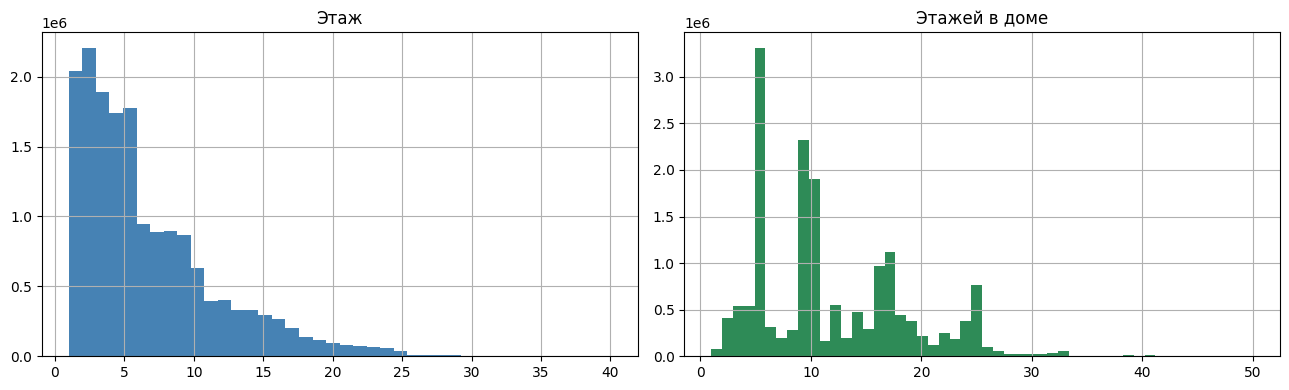

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[df['level'].between(1, 40)]['level'].hist(ax=axes[0], bins=40, color='steelblue')
axes[0].set_title('Этаж')

df[df['levels'].between(1, 50)]['levels'].hist(ax=axes[1], bins=50, color='seagreen')
axes[1].set_title('Этажей в доме')

plt.tight_layout()
plt.show()

## 4. Географическое распределение

Уникальных регионов: 85

Топ-10 регионов по количеству объявлений:
region
54.0    1662265
77.0    1504929
23.0    1478217
50.0    1232453
78.0    1223125
72.0     988880
66.0     667714
61.0     629709
24.0     514590
74.0     487302
Name: count, dtype: int64


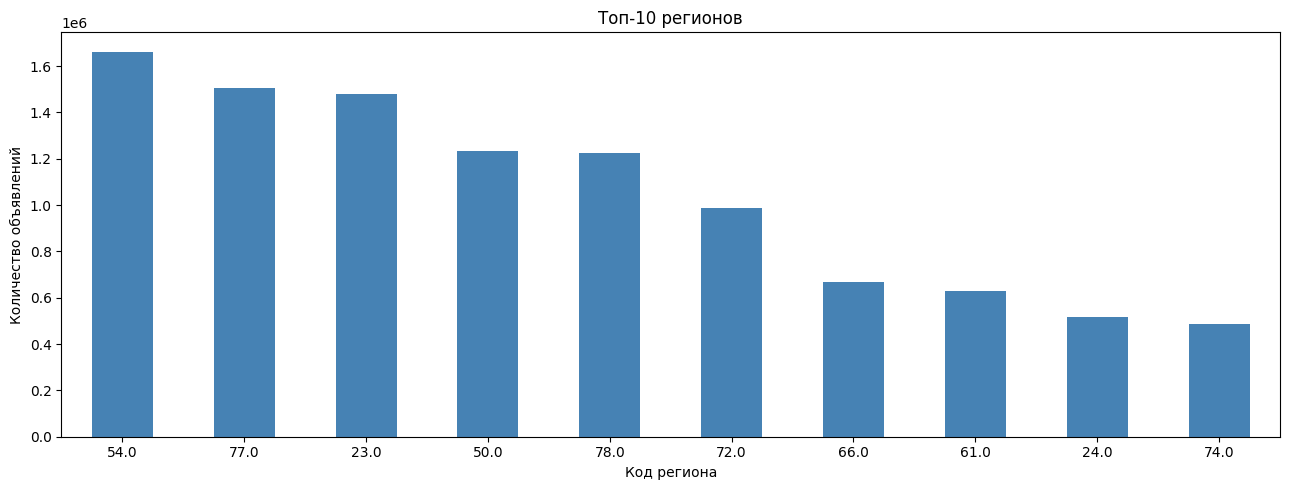

In [58]:
print(f'Уникальных регионов: {df["region"].nunique()}')
print()
top10 = df['region'].value_counts().head(10)
print('Топ-10 регионов по количеству объявлений:')
print(top10)

top10.plot(kind='bar', color='steelblue')
plt.title('Топ-10 регионов')
plt.xlabel('Код региона')
plt.ylabel('Количество объявлений')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

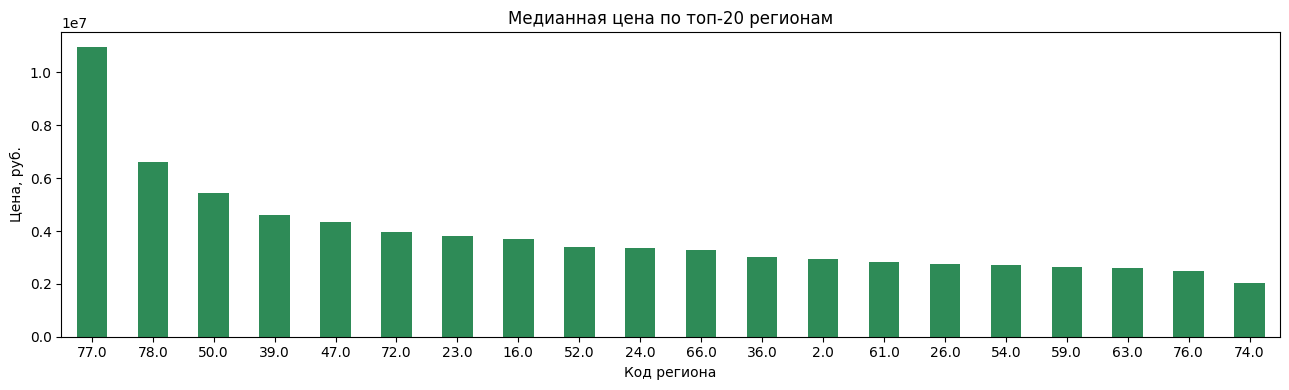

In [59]:
# Медианная цена по топ-20 регионам
top20_regions = df['region'].value_counts().head(20).index
median_by_region = (
    df_clean[df_clean['region'].isin(top20_regions)]
    .groupby('region')['price']
    .median()
    .sort_values(ascending=False)
)
median_by_region.plot(kind='bar', color='seagreen', figsize=(13, 4))
plt.title('Медианная цена по топ-20 регионам')
plt.xlabel('Код региона')
plt.ylabel('Цена, руб.')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Корреляции

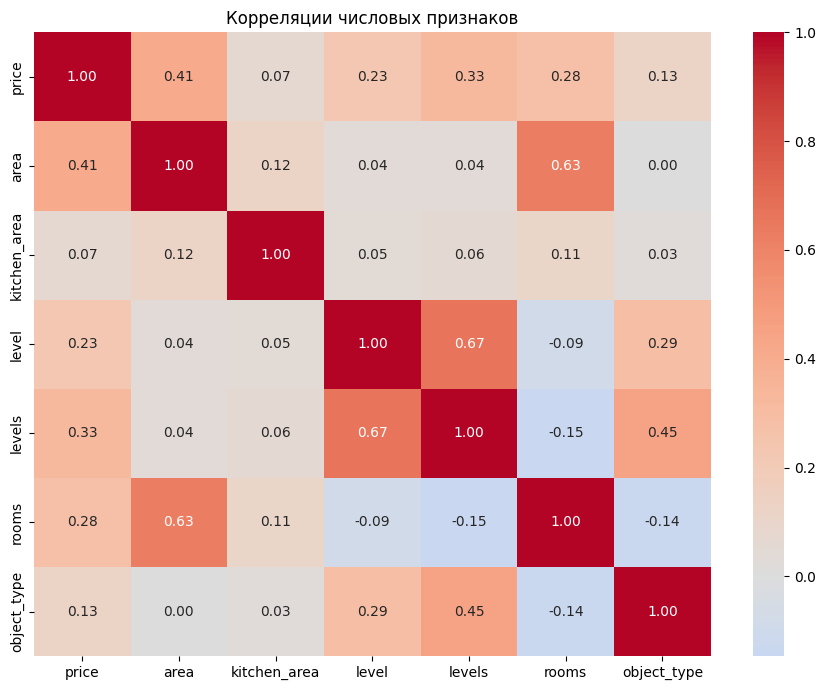

In [60]:
num_cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms', 'object_type']
corr = df_clean[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков')
plt.tight_layout()
plt.show()

## 6. Сравнение источников

In [61]:
print('Статистика по источникам (цена, без выбросов):')
display(
    df_clean.groupby('source')['price']
    .describe()
    .map(lambda x: f'{x:,.0f}')
)

print()
print('Средние значения признаков по источникам:')
display(
    df_clean.groupby('source')[['price', 'area', 'rooms', 'level', 'levels']]
    .mean()
    .round(2)
)

Статистика по источникам (цена, без выбросов):


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
all_v2,"5,430,548","4,040,711","3,472,404","300,100","1,950,000","2,975,000","4,776,800","29,999,999"
input_data,"11,140,993","5,268,360","4,339,855","300,005","2,600,000","3,950,000","6,291,600","29,999,999"



Средние значения признаков по источникам:


,price,area,rooms,level,levels
source,,,,,
all_v2,4040710.75,53.28,1.71,6.21,11.39
input_data,5268360.05,51.68,1.69,6.38,11.70


## 7. Карта: выборка объектов по регионам

Точек на карте: 935


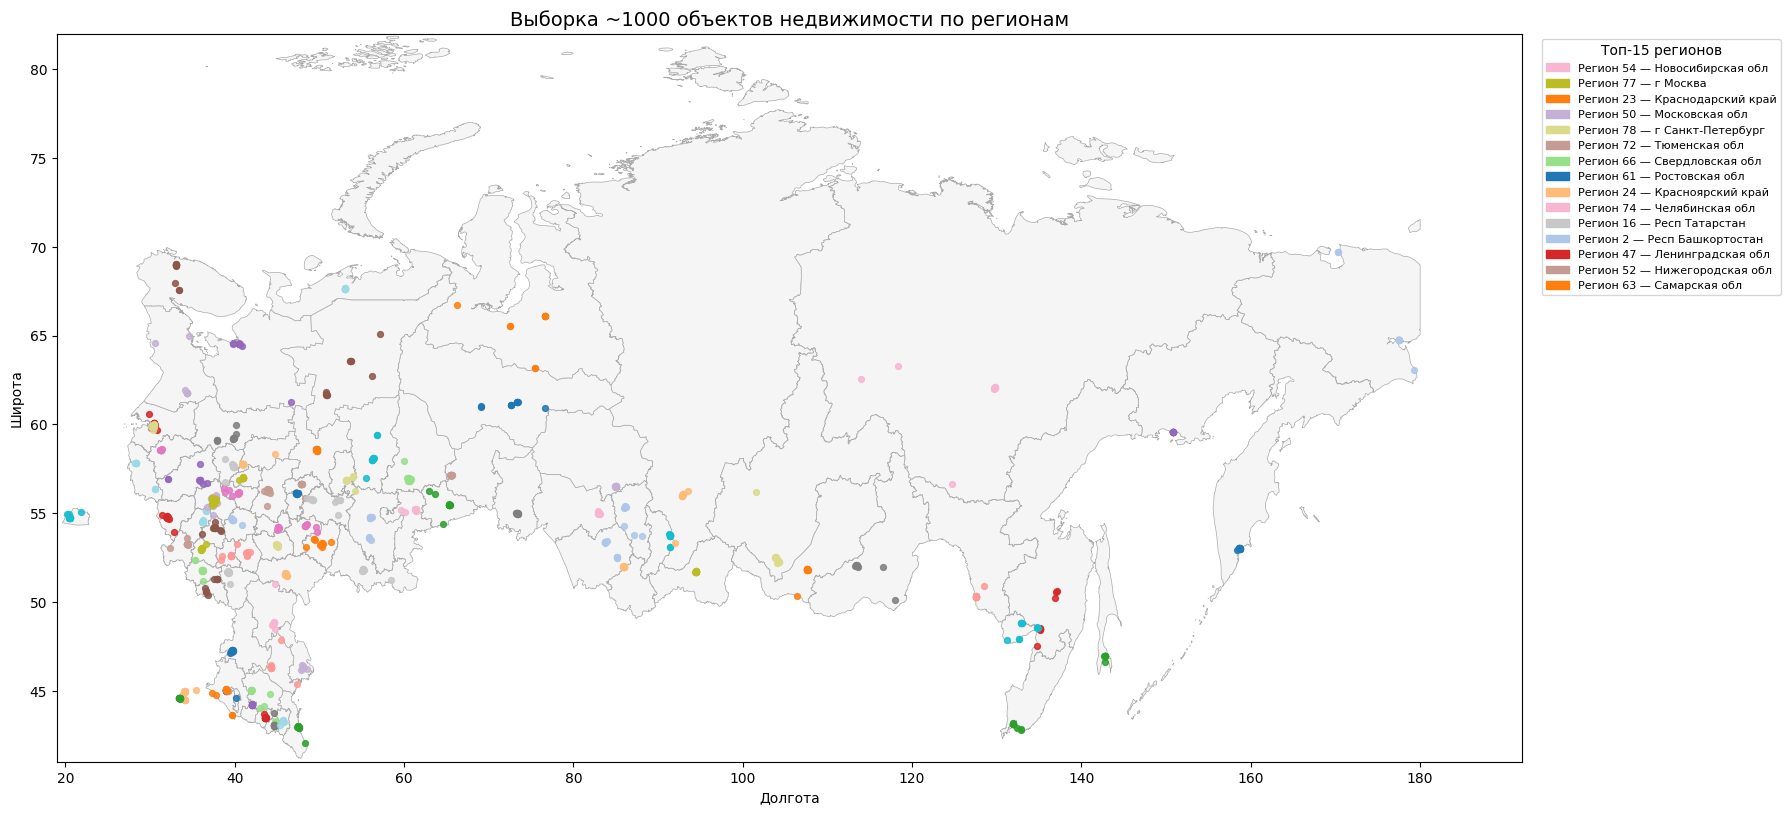

In [78]:
import geopandas as gpd
import matplotlib.patches as mpatches

regions_geo = gpd.read_file('../data/russia_regions.geojson').to_crs('EPSG:4326')

# Справочник русских названий регионов
reg_ref = pd.read_csv('../data/russia_region_codes.csv', dtype={'kladr_id': str}, encoding='utf-8')
reg_ref['region_code'] = reg_ref['kladr_id'].str[:2].astype(int)
code_to_name = reg_ref.set_index('region_code')['name_with_type'].to_dict()
code_to_name[91] = 'Респ Крым'
code_to_name[92] = 'г Севастополь'

df_valid = df.dropna(subset=['geo_lat', 'geo_lon']).copy()
df_valid['region'] = df_valid['region'].astype(int)

n_per_region = max(1, 1000 // df_valid['region'].nunique())
pieces = []
for region, group in df_valid.groupby('region'):
    pieces.append(group.sample(min(len(group), n_per_region), random_state=42))
sample = pd.concat(pieces, ignore_index=True)
print(f'Точек на карте: {len(sample)}')

unique_regions = sorted(sample['region'].unique())
cmap = plt.colormaps['tab20']
region_color = {r: cmap(i % 20) for i, r in enumerate(unique_regions)}

fig, ax = plt.subplots(figsize=(18, 11))
regions_geo.plot(ax=ax, color='#f5f5f5', edgecolor='#aaaaaa', linewidth=0.5)

for region, group in sample.groupby('region'):
    ax.scatter(group['geo_lon'], group['geo_lat'], s=18, color=region_color[region], alpha=0.85, zorder=3)

ax.set_xlim(19, 192)
ax.set_ylim(41, 82)
ax.set_title('Выборка ~1000 объектов недвижимости по регионам', fontsize=14)
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')

# Топ-15 по числу записей в полном датасете
top_regions = df_valid['region'].value_counts().head(15).index.tolist()
handles = [
    mpatches.Patch(color=region_color[r], label=f'Регион {r} — {code_to_name.get(r, "?")}')
    for r in top_regions
]
ax.legend(handles=handles, title='Топ-15 регионов', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()